# Week 3: Advanced Data Analysis, Statistical Validation & Feature Engineering

## Employee Attrition Analysis

**AnalystLab Africa — Data Science Internship Programme**

This notebook continues the Week 1 (Exploratory Data Analysis) and Week 2 (Feature Engineering & Preprocessing) work on the **IBM HR Analytics – Employee Attrition & Performance** dataset.

This notebook builds directly on the **Week 2 cleaned dataset** (`cleaned_employee_attrition.csv`). No re-cleaning of the raw source data is performed here — only deeper analysis, statistical validation, and additional feature engineering, per the Week 3 brief.


## Part 1: Review of Previous Work — Project Continuity Summary

**Business problem.** AnalystLab Africa Consulting has been engaged to help a client organisation understand and reduce employee attrition. Losing employees carries recruitment cost, productivity disruption, loss of institutional knowledge, and added pressure on remaining staff.

**Project objective.** Identify the factors most strongly associated with employee attrition and translate them into actionable, evidence-based retention recommendations.

**Target variable.** `Attrition` (`Yes`/`No`), encoded as `AttritionFlag` (1 = left, 0 = stayed). This was confirmed, not merely potential — it is the outcome variable for the eventual Week 4 classification model.

**Key findings from Week 1 (EDA).** Overtime, business travel frequency, job role, age, income, and organisational tenure emerged as variables associated with differing attrition patterns.

**Major data-quality issues identified in Week 1.** No missing values were present in the raw dataset. Several columns were constant or pure identifiers (`EmployeeCount`, `Over18`, `StandardHours`, `EmployeeNumber`) and carried no analytical value.

**Major cleaning/preprocessing actions completed in Week 2.**
- Removed constant columns and the `EmployeeNumber` identifier.
- Encoded the target as a binary `AttritionFlag`.
- Engineered ten HR features (`AgeGroup`, `IncomeBand`, `TenureGroup`, `EarlyCareerFlag`, `LongCommuteFlag`, `YearsWithoutPromotion`, `RoleTenureRatio`, `ManagerTenureRatio`, `CompanyExperienceRatio`, `OvertimeRiskFlag`).
- Performed a stratified 80/20 train/test split, then fit scaling (`StandardScaler`) and encoding (`OneHotEncoder`) on the training set only to prevent leakage.
- Exported a human-readable `cleaned_employee_attrition.csv` and a model-ready `employee_attrition_ml_ready.csv`.

**Remaining questions for Week 3.** Which relationships are statistically significant rather than just visually suggestive? Are the Week 2 engineered features actually informative, or are some redundant/collinear? Are there additional features — particularly ones that combine satisfaction, pay competitiveness, or career-mobility signals — that would sharpen a future predictive model?


In [1]:
import warnings
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
ALPHA = 0.05  # significance level for all hypothesis tests

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
try:
    from google.colab import files

    print("Upload: cleaned_employee_attrition.csv (Week 2 output)")
    uploaded = files.upload()
    source_filename = next(iter(uploaded))
    import io
    df = pd.read_csv(io.BytesIO(uploaded[source_filename]))

except ImportError:
    from pathlib import Path
    DATA_PATH = Path("cleaned_employee_attrition.csv")
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            "cleaned_employee_attrition.csv not found. "
            "Place the Week 2 output CSV in the same folder as this notebook."
        )
    source_filename = DATA_PATH.name
    df = pd.read_csv(DATA_PATH)

print(f"Loaded: {source_filename}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Loaded: cleaned_employee_attrition.csv
Rows: 1,470 | Columns: 42


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag,AgeGroup,IncomeBand,TenureGroup,EarlyCareerFlag,LongCommuteFlag,YearsWithoutPromotion,RoleTenureRatio,ManagerTenureRatio,CompanyExperienceRatio,OvertimeRiskFlag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,1,36-45,Upper-Middle,6-10 years,0,0,6,0.667,0.833,0.750,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,0,46-55,Upper-Middle,6-10 years,0,0,9,0.700,0.700,1.000,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,1,36-45,Low,0-1 years,0,0,0,0.000,0.000,0.000,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0,26-35,Low,6-10 years,0,0,5,0.875,0.000,1.000,1
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,0,26-35,Lower-Middle,2-3 years,0,0,0,1.000,1.000,0.333,0


In [3]:
# Sanity check — confirm this is the Week 2 cleaned/engineered dataset, not raw data
expected_week2_features = [
    "AttritionFlag", "AgeGroup", "IncomeBand", "TenureGroup",
    "EarlyCareerFlag", "LongCommuteFlag", "YearsWithoutPromotion",
    "RoleTenureRatio", "ManagerTenureRatio", "CompanyExperienceRatio", "OvertimeRiskFlag"
]
missing = [c for c in expected_week2_features if c not in df.columns]
assert not missing, f"This does not look like the Week 2 cleaned dataset — missing {missing}"
print("Confirmed: Week 2 cleaned dataset loaded successfully. No re-cleaning performed.")

target = "Attrition"
target_flag = "AttritionFlag"


Confirmed: Week 2 cleaned dataset loaded successfully. No re-cleaning performed.


## Part 2: Advanced Exploratory Data Analysis

Week 1 covered introductory EDA. This section goes deeper — distribution shape, bivariate and multivariate relationships, and target-variable analysis — to surface insights that directly inform the statistical testing and feature engineering that follow.


### 2.1 Numerical Analysis — Distributions, Skewness, Variability

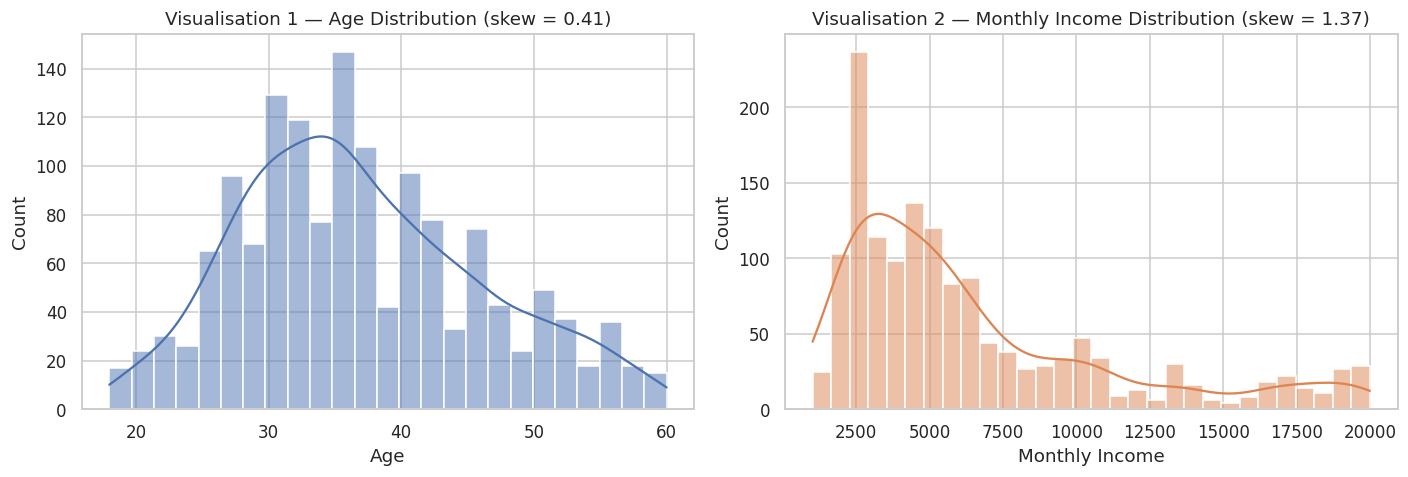

Age is only mildly right-skewed and roughly bell-shaped.
Monthly Income is strongly right-skewed — a small group of senior/high-income
employees pulls the mean well above the median, which matters for choosing
the right statistical test later in this notebook.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["Age"], kde=True, bins=25, color="#4C72B0", ax=axes[0])
axes[0].set_title(f"Visualisation 1 — Age Distribution (skew = {df['Age'].skew():.2f})")
axes[0].set_xlabel("Age")

sns.histplot(df["MonthlyIncome"], kde=True, bins=30, color="#DD8452", ax=axes[1])
axes[1].set_title(f"Visualisation 2 — Monthly Income Distribution (skew = {df['MonthlyIncome'].skew():.2f})")
axes[1].set_xlabel("Monthly Income")

plt.tight_layout()
plt.show()

print("Age is only mildly right-skewed and roughly bell-shaped.")
print("Monthly Income is strongly right-skewed — a small group of senior/high-income")
print("employees pulls the mean well above the median, which matters for choosing")
print("the right statistical test later in this notebook.")


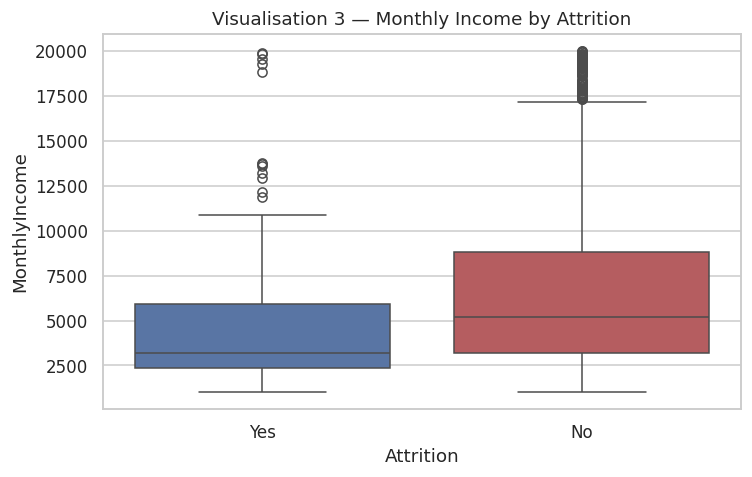

Attrition
No    5,204.000
Yes   3,202.000
Name: Median Monthly Income, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Visualisation 3 — Monthly Income by Attrition")
plt.tight_layout()
plt.show()

print(df.groupby("Attrition")["MonthlyIncome"].median().rename("Median Monthly Income"))


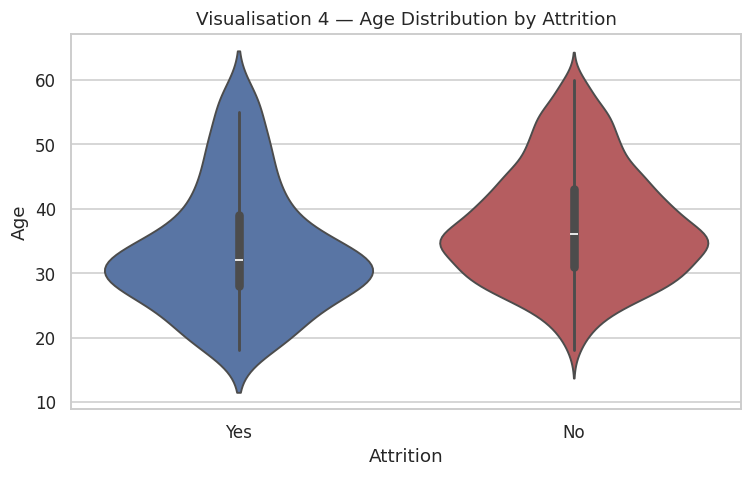

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(data=df, x="Attrition", y="Age", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Visualisation 4 — Age Distribution by Attrition")
plt.tight_layout()
plt.show()


### 2.2 Categorical Analysis — Frequencies, Group Comparisons, Relationship to Target

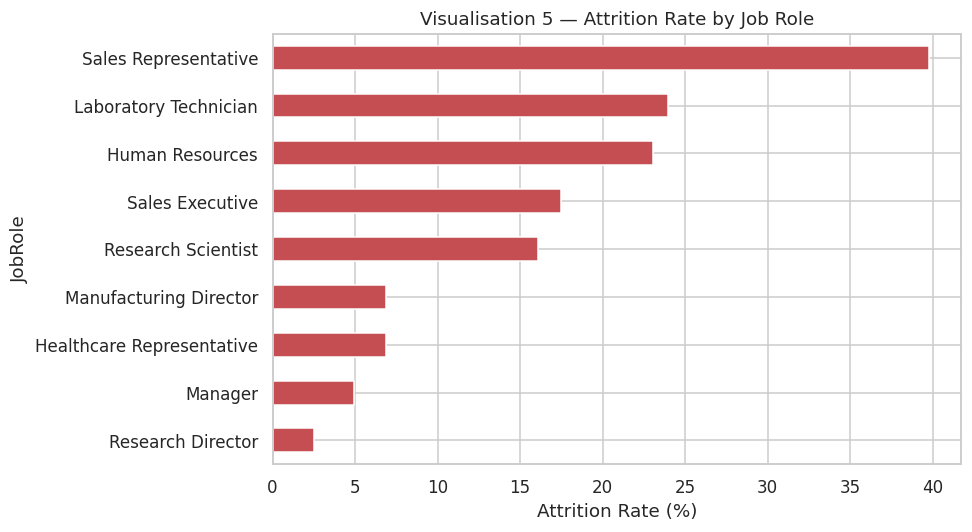

,Attrition Rate (%)
JobRole,
Sales Representative,39.800
Laboratory Technician,23.900
Human Resources,23.100
Sales Executive,17.500
Research Scientist,16.100
Manufacturing Director,6.900
Healthcare Representative,6.900
Manager,4.900
Research Director,2.500


In [7]:
attrition_by_role = (
    df.groupby("JobRole")["AttritionFlag"].mean().sort_values(ascending=False) * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
attrition_by_role.plot(kind="barh", color="#C44E52", ax=ax)
ax.set_title("Visualisation 5 — Attrition Rate by Job Role")
ax.set_xlabel("Attrition Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

attrition_by_role.round(1).to_frame("Attrition Rate (%)")


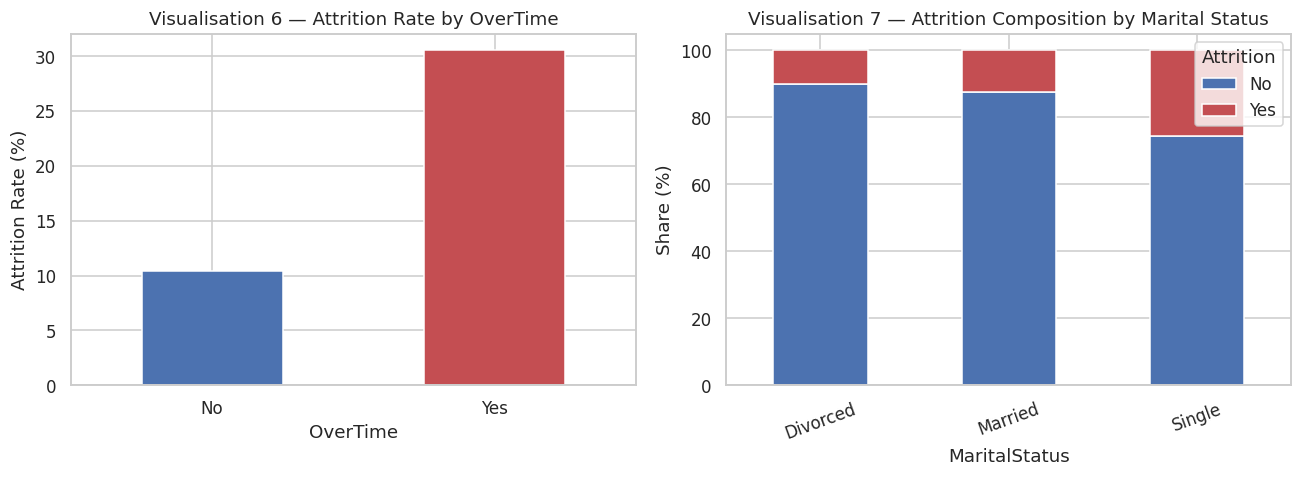

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

attrition_by_ot = df.groupby("OverTime")["AttritionFlag"].mean() * 100
attrition_by_ot.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Visualisation 6 — Attrition Rate by OverTime")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(df["MaritalStatus"], df["Attrition"], normalize="index").mul(100).plot(
    kind="bar", stacked=True, color=["#4C72B0", "#C44E52"], ax=axes[1]
)
axes[1].set_title("Visualisation 7 — Attrition Composition by Marital Status")
axes[1].set_ylabel("Share (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


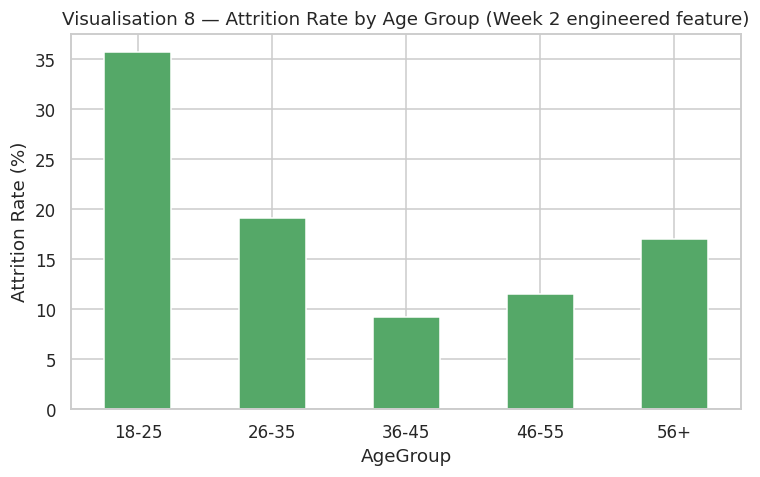

In [9]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
attrition_by_age = (
    df.groupby("AgeGroup", observed=True)["AttritionFlag"].mean().reindex(age_order) * 100
)

fig, ax = plt.subplots(figsize=(7, 4.5))
attrition_by_age.plot(kind="bar", color="#55A868", ax=ax)
ax.set_title("Visualisation 8 — Attrition Rate by Age Group (Week 2 engineered feature)")
ax.set_ylabel("Attrition Rate (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


### 2.3 Bivariate Analysis — Numerical vs Categorical, Categorical vs Categorical

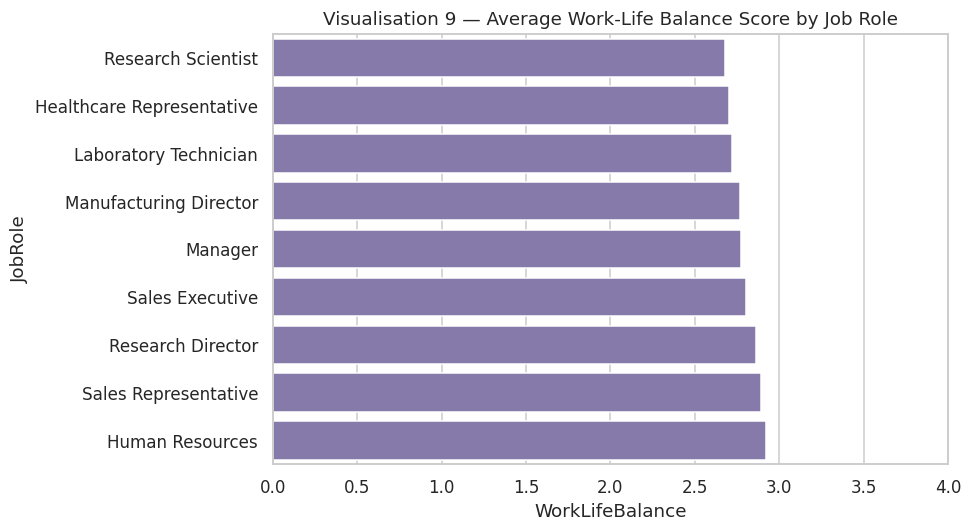

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
role_order = df.groupby("JobRole")["WorkLifeBalance"].mean().sort_values().index
sns.barplot(
    data=df, x="WorkLifeBalance", y="JobRole", order=role_order,
    color="#8172B2", errorbar=None, ax=ax
)
ax.set_title("Visualisation 9 — Average Work-Life Balance Score by Job Role")
ax.set_xlim(0, 4)
plt.tight_layout()
plt.show()


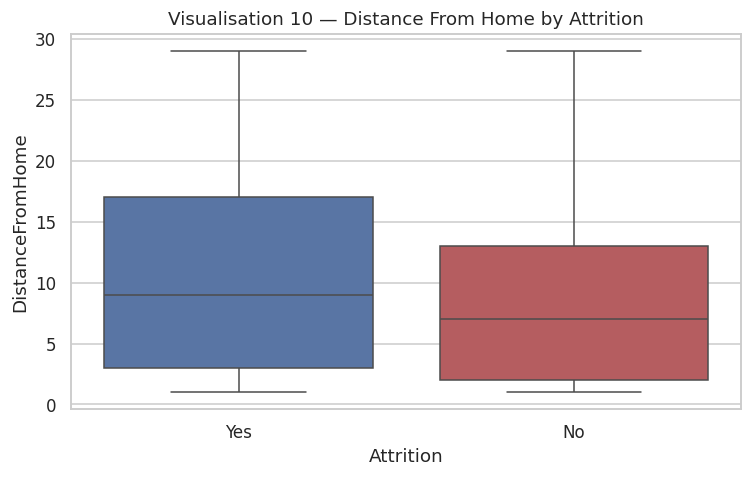

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="Attrition", y="DistanceFromHome", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Visualisation 10 — Distance From Home by Attrition")
plt.tight_layout()
plt.show()


### 2.4 Multivariate Analysis — Correlation, Pair Relationships, Grouped Comparisons

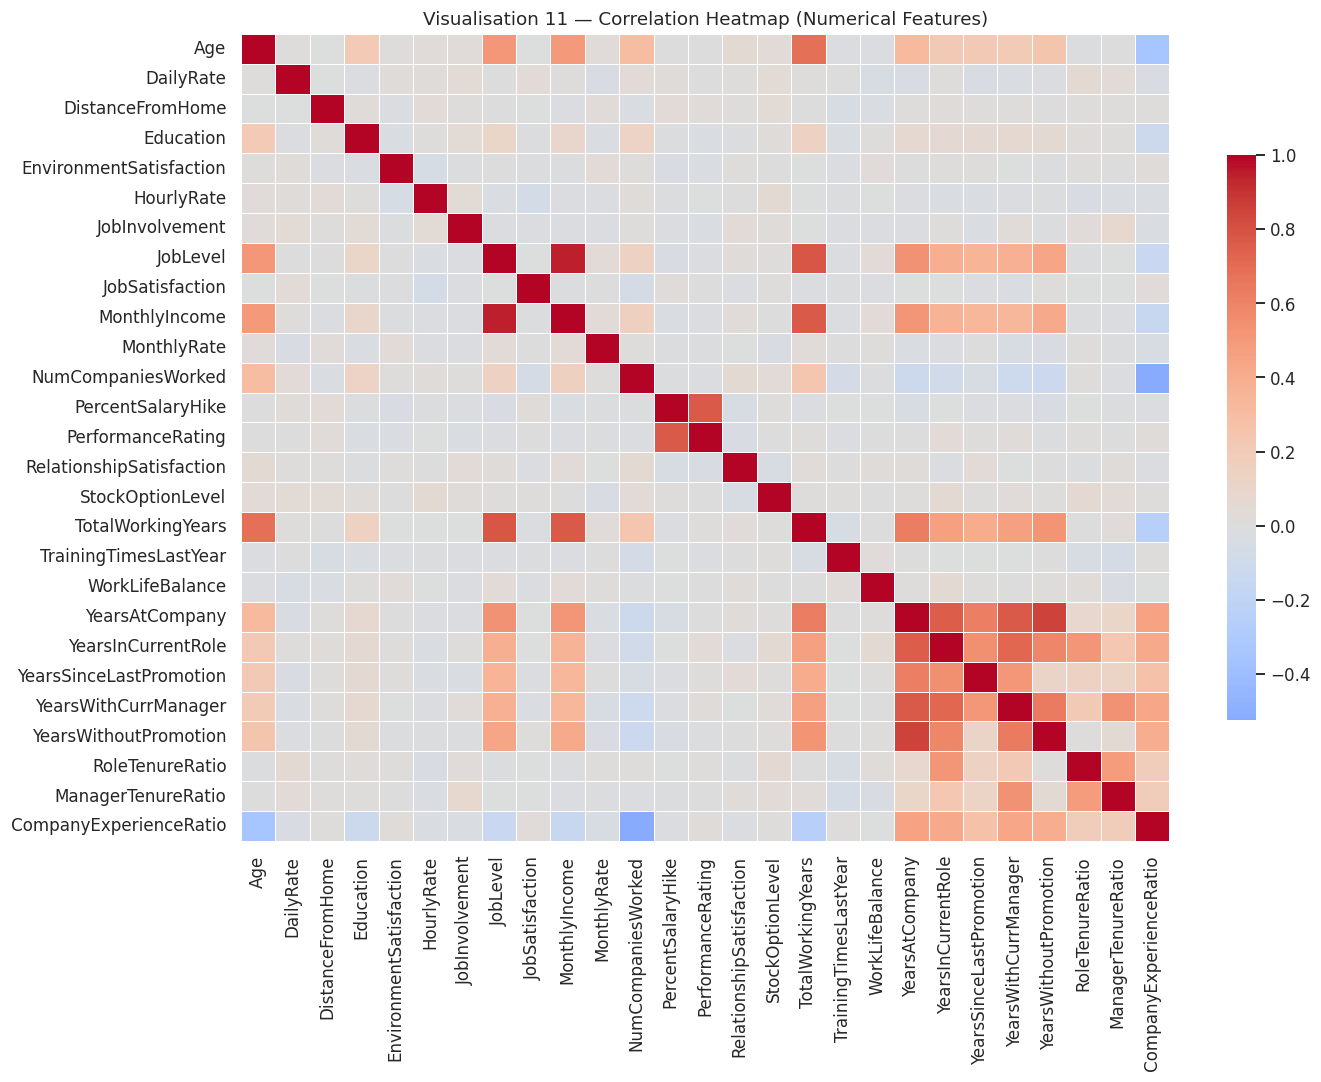

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ("AttritionFlag", "EarlyCareerFlag", "LongCommuteFlag", "OvertimeRiskFlag")]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.4, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Visualisation 11 — Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()


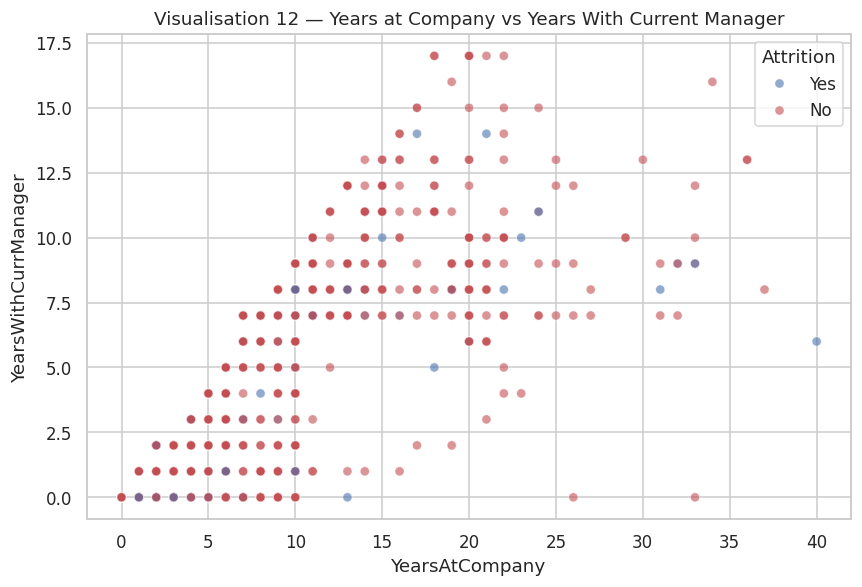

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(
    data=df, x="YearsAtCompany", y="YearsWithCurrManager",
    hue="Attrition", palette=["#4C72B0", "#C44E52"], alpha=0.6, ax=ax
)
ax.set_title("Visualisation 12 — Years at Company vs Years With Current Manager")
plt.tight_layout()
plt.show()


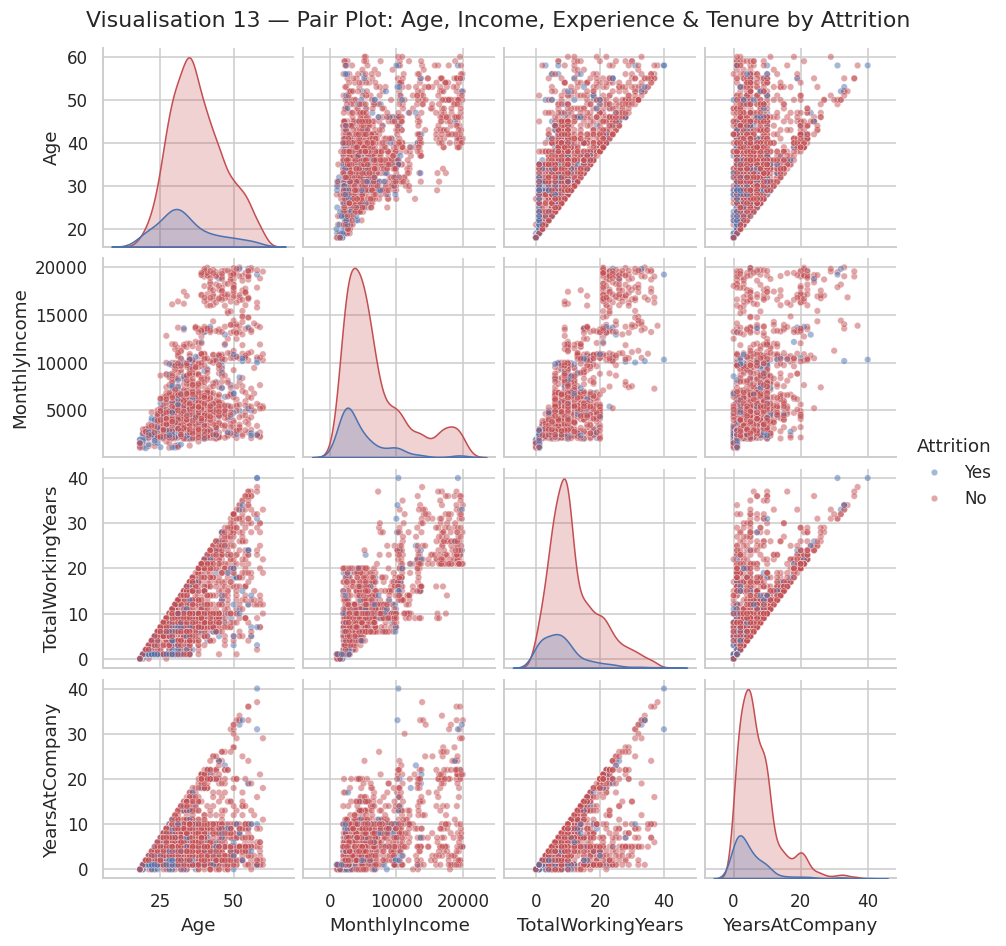

In [14]:
pairplot_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "Attrition"]
g = sns.pairplot(
    df[pairplot_cols], hue="Attrition", palette=["#4C72B0", "#C44E52"],
    diag_kind="kde", plot_kws={"alpha": 0.5, "s": 18}, height=2.1
)
g.fig.suptitle("Visualisation 13 — Pair Plot: Age, Income, Experience & Tenure by Attrition", y=1.02)
plt.show()


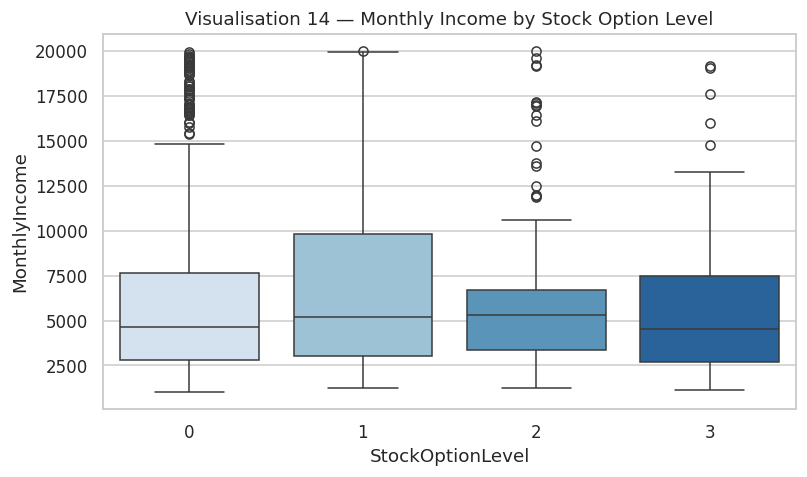

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=df, x="StockOptionLevel", y="MonthlyIncome", palette="Blues", ax=ax)
ax.set_title("Visualisation 14 — Monthly Income by Stock Option Level")
plt.tight_layout()
plt.show()


**Advanced EDA summary of new insights (not covered in Week 1):**
- Monthly Income is strongly right-skewed (skew ≈ 1.37) — this rules out standard t-tests on raw income and points to a non-parametric test, confirmed statistically in Part 3.
- Sales Representatives and Laboratory Technicians show markedly higher attrition rates than Managers or Research Directors — role-level risk is uneven, not uniform.
- Single employees leave at roughly double the rate of married employees, and employees who work overtime leave at roughly triple the rate of those who don't.
- `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` are all strongly correlated with each other — a multicollinearity signal that is investigated formally in Part 5.
- Distance from home is modestly but consistently higher among employees who left.


## Part 3: Statistical Hypothesis Testing and Validation

Five tests are performed — one more than the minimum of four — covering a chi-square test of independence, two non-parametric group-comparison tests, a non-parametric multi-group test, and a correlation significance test. Non-parametric tests are used wherever a numerical variable is meaningfully skewed, since the parametric alternatives assume approximate normality.


### Test 1 — Attrition vs. Overtime (Chi-Square Test of Independence)

- **Business question:** Is an employee's likelihood of leaving related to whether they work overtime?
- **Objective:** Test whether `Attrition` and `OverTime` are statistically independent.
- **H₀:** Attrition and OverTime are independent (no association).
- **H₁:** Attrition and OverTime are associated.
- **Method:** Chi-square test of independence — appropriate because both variables are categorical (binary).


In [16]:
contingency_overtime = pd.crosstab(df["OverTime"], df["Attrition"])
chi2_ot, p_ot, dof_ot, expected_ot = stats.chi2_contingency(contingency_overtime)

print(contingency_overtime)
print(f"\nChi-square statistic: {chi2_ot:.3f}")
print(f"Degrees of freedom: {dof_ot}")
print(f"P-value: {p_ot:.6g}")

decision = "Reject H0" if p_ot < ALPHA else "Fail to reject H0"
print(f"Decision at alpha={ALPHA}: {decision}")


Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Chi-square statistic: 87.564
Degrees of freedom: 1
P-value: 8.15842e-21
Decision at alpha=0.05: Reject H0


**Interpretation:** The p-value is far below 0.05, so H₀ is rejected — overtime and attrition are statistically associated. Employees who work overtime leave at roughly **30.5%**, nearly three times the **10.4%** rate among those who don't.

**Business implication:** Overtime is one of the strongest attrition signals in the dataset. Workload and scheduling policy for overtime-heavy roles deserve direct attention as a retention lever.


### Test 2 — Attrition vs. Marital Status (Chi-Square Test of Independence)

- **Business question:** Does marital status relate to attrition risk?
- **Objective:** Test whether `Attrition` and `MaritalStatus` are independent.
- **H₀:** Attrition and Marital Status are independent.
- **H₁:** Attrition and Marital Status are associated.
- **Method:** Chi-square test of independence — both variables are categorical.


In [17]:
contingency_marital = pd.crosstab(df["MaritalStatus"], df["Attrition"])
chi2_m, p_m, dof_m, expected_m = stats.chi2_contingency(contingency_marital)

print(contingency_marital)
print(f"\nChi-square statistic: {chi2_m:.3f}")
print(f"Degrees of freedom: {dof_m}")
print(f"P-value: {p_m:.6g}")

decision = "Reject H0" if p_m < ALPHA else "Fail to reject H0"
print(f"Decision at alpha={ALPHA}: {decision}")

print("\nAttrition rate by marital status:")
print((df.groupby('MaritalStatus')['AttritionFlag'].mean() * 100).round(1))


Attrition       No  Yes
MaritalStatus          
Divorced       294   33
Married        589   84
Single         350  120

Chi-square statistic: 46.164
Degrees of freedom: 2
P-value: 9.45551e-11
Decision at alpha=0.05: Reject H0

Attrition rate by marital status:
MaritalStatus
Divorced   10.100
Married    12.500
Single     25.500
Name: AttritionFlag, dtype: float64


**Interpretation:** H₀ is rejected — marital status is significantly associated with attrition. Single employees leave at roughly **25.5%**, more than double the rate for married (**12.5%**) or divorced (**10.1%**) employees.

**Business implication:** Life-stage-related factors (e.g. relocation flexibility, financial pressure, or stability) may be at play. Retention programmes could benefit from segment-aware engagement rather than a one-size-fits-all approach — while being mindful not to discriminate on the basis of marital status in any resulting policy.


### Test 3 — Monthly Income by Attrition (Mann-Whitney U Test)

- **Business question:** Do employees who leave earn less than those who stay?
- **Objective:** Compare the distribution of `MonthlyIncome` between the two Attrition groups.
- **H₀:** The distribution of Monthly Income is the same for employees who leave and employees who stay.
- **H₁:** The distribution of Monthly Income differs between the two groups.
- **Method selected:** Mann-Whitney U test (non-parametric).
- **Justification:** Monthly Income is strongly right-skewed (skew ≈ 1.37, confirmed with a Shapiro-Wilk test below), so the normality assumption behind an independent-samples t-test is not reasonably met. The Mann-Whitney U test compares distributions/medians without that assumption.


In [18]:
shapiro_stat, shapiro_p = stats.shapiro(df["MonthlyIncome"].sample(500, random_state=RANDOM_STATE))
print(f"Shapiro-Wilk normality check on Monthly Income (n=500 sample): W={shapiro_stat:.4f}, p={shapiro_p:.3g}")
print("-> p < 0.05: Monthly Income is not normally distributed; a non-parametric test is appropriate.\n")

income_left = df.loc[df["Attrition"] == "Yes", "MonthlyIncome"]
income_stayed = df.loc[df["Attrition"] == "No", "MonthlyIncome"]

u_stat, p_income = stats.mannwhitneyu(income_left, income_stayed, alternative="two-sided")

print(f"Median Monthly Income — Left: {income_left.median():,.0f} | Stayed: {income_stayed.median():,.0f}")
print(f"U statistic: {u_stat:.1f}")
print(f"P-value: {p_income:.6g}")

decision = "Reject H0" if p_income < ALPHA else "Fail to reject H0"
print(f"Decision at alpha={ALPHA}: {decision}")


Shapiro-Wilk normality check on Monthly Income (n=500 sample): W=0.8447, p=9.63e-22
-> p < 0.05: Monthly Income is not normally distributed; a non-parametric test is appropriate.

Median Monthly Income — Left: 3,202 | Stayed: 5,204
U statistic: 100620.5
P-value: 2.95083e-14
Decision at alpha=0.05: Reject H0


**Interpretation:** H₀ is rejected. Employees who left earn a median of roughly **$3,202/month** versus **$5,204/month** for those who stayed — a substantial and statistically significant gap.

**Business implication:** Compensation is a meaningful factor in attrition. This motivates the `CompaRatio` feature engineered in Part 4, which checks pay competitiveness *within* job level rather than raw income alone — raw income partly reflects seniority, not just competitiveness.


### Test 4 — Job Satisfaction Across Job Roles (Kruskal-Wallis H Test)

- **Business question:** Does job satisfaction differ meaningfully by job role?
- **Objective:** Compare `JobSatisfaction` across the nine `JobRole` categories.
- **H₀:** Job Satisfaction has the same distribution across all job roles.
- **H₁:** At least one job role differs from the others in Job Satisfaction.
- **Method selected:** Kruskal-Wallis H test (non-parametric one-way ANOVA equivalent).
- **Justification:** `JobSatisfaction` is an ordinal 1–4 survey scale, not a continuous normally-distributed measure, and there are more than two groups being compared — Kruskal-Wallis is the appropriate choice over a standard ANOVA.


In [19]:
satisfaction_groups = [g["JobSatisfaction"].values for _, g in df.groupby("JobRole")]
h_stat, p_satisfaction = stats.kruskal(*satisfaction_groups)

print(f"H statistic: {h_stat:.3f}")
print(f"P-value: {p_satisfaction:.4f}")

decision = "Reject H0" if p_satisfaction < ALPHA else "Fail to reject H0"
print(f"Decision at alpha={ALPHA}: {decision}")

print("\nMean Job Satisfaction by role:")
print(df.groupby("JobRole")["JobSatisfaction"].mean().sort_values().round(2))


H statistic: 3.451
P-value: 0.9030
Decision at alpha=0.05: Fail to reject H0

Mean Job Satisfaction by role:
JobRole
Human Resources             2.560
Manufacturing Director      2.680
Laboratory Technician       2.690
Research Director           2.700
Manager                     2.710
Sales Representative        2.730
Sales Executive             2.750
Research Scientist          2.770
Healthcare Representative   2.790
Name: JobSatisfaction, dtype: float64


**Interpretation:** H₀ is **not** rejected (p ≈ 0.90) — there is no statistically significant difference in job satisfaction across job roles. Mean scores cluster tightly between 2.56 and 2.79 on the 1–4 scale for every role.

**Business implication:** This is a useful negative finding — job dissatisfaction is not concentrated in specific roles, so it is not, by itself, a good explanation for the role-level attrition differences seen in Part 2 (Visualisation 5). Whatever drives the higher attrition in Sales Representative and Laboratory Technician roles, it is more likely tied to workload, overtime, or compensation structure than to reported satisfaction. This is exactly the kind of result that should stop an analyst from over-interpreting a visually suggestive pattern without testing it.


### Test 5 — Years at Company vs. Years With Current Manager (Spearman Correlation)

- **Business question:** Is organisational tenure related to manager tenure, and is that relationship strong enough to be a multicollinearity concern for later modelling?
- **Objective:** Test the strength and significance of the monotonic relationship between `YearsAtCompany` and `YearsWithCurrManager`.
- **H₀:** There is no monotonic correlation between the two variables (ρ = 0).
- **H₁:** There is a monotonic correlation between the two variables (ρ ≠ 0).
- **Method selected:** Spearman rank correlation.
- **Justification:** Both variables are counts of years with a floor at zero and are not normally distributed (many employees cluster at low tenure); Spearman is robust to that skew and to outliers, unlike Pearson correlation.


In [20]:
rho, p_rho = stats.spearmanr(df["YearsAtCompany"], df["YearsWithCurrManager"])

print(f"Spearman rho: {rho:.3f}")
print(f"P-value: {p_rho:.3g}")

decision = "Reject H0" if p_rho < ALPHA else "Fail to reject H0"
print(f"Decision at alpha={ALPHA}: {decision}")


Spearman rho: 0.843
P-value: 0
Decision at alpha=0.05: Reject H0


**Interpretation:** H₀ is rejected — there is a strong, statistically significant positive correlation (ρ ≈ 0.84) between years at the company and years with the current manager.

**Business implication:** This is expected (you can't have a longer manager relationship than your total tenure) but the strength of the relationship flags a **multicollinearity risk** for Week 4 modelling if both variables, plus `YearsInCurrentRole`, are included together. This is investigated formally in Part 5's feature evaluation.


## Part 4: Advanced Feature Engineering

Four new features are engineered here — one more than the minimum of three — each directly motivated by an Advanced EDA or statistical finding above, rather than created speculatively. The ten features created in Week 2 (`AgeGroup`, `IncomeBand`, `TenureGroup`, etc.) are left untouched.


### 4.1 `SatisfactionIndex`

**How:** The mean of the four ordinal satisfaction/balance scores — `EnvironmentSatisfaction`, `JobSatisfaction`, `RelationshipSatisfaction`, and `WorkLifeBalance` — each on a 1–4 scale.

**Why:** Part 2/3 examined these scores individually; a composite index tests whether *overall* sentiment (rather than any single dimension) relates to attrition, and is more stable than any one noisy 1–4 survey item.

**Business meaning:** A single, interpretable "how content is this employee overall" score for HR dashboards.

**Potential modelling value:** Reduces four correlated ordinal columns to one aggregate signal, which can help a future model generalise instead of overfitting to noise in any single item.


In [21]:
satisfaction_cols = ["EnvironmentSatisfaction", "JobSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]
df["SatisfactionIndex"] = df[satisfaction_cols].mean(axis=1)

print(df["SatisfactionIndex"].describe().round(2))
print()
print(df.groupby("Attrition")["SatisfactionIndex"].mean().round(3))


count   1,470.000
mean        2.730
std         0.510
min         1.000
25%         2.500
50%         2.750
75%         3.000
max         4.000
Name: SatisfactionIndex, dtype: float64

Attrition
No    2.766
Yes   2.547
Name: SatisfactionIndex, dtype: float64


### 4.2 `CompaRatio`

**How:** `MonthlyIncome` divided by the *average* `MonthlyIncome` for that employee's `JobLevel`. A value of 1.0 means the employee earns exactly the average for their level; below 1.0 means below-average pay for their level.

**Why:** Test 3 showed income differs significantly by attrition status, but raw income is confounded with seniority (`JobLevel` correlates with `MonthlyIncome` at r ≈ 0.95, per the Part 2 correlation heatmap). `CompaRatio` isolates pay *competitiveness within level* — a junior employee on $3,000 and a director on $15,000 can both be perfectly well paid for their level, and raw income alone can't tell them apart.

**Business meaning:** A standard compensation-analytics metric ("compa-ratio") used in real HR/reward functions to flag under- or over-paid employees relative to peers at the same level.

**Potential modelling value:** A cleaner, de-confounded pay-fairness signal than raw `MonthlyIncome` for a future attrition model.


In [22]:
df["CompaRatio"] = df["MonthlyIncome"] / df.groupby("JobLevel")["MonthlyIncome"].transform("mean")

print(df["CompaRatio"].describe().round(3))
print()
below_avg = df[df["CompaRatio"] < 0.9]
print(f"Employees paid <90% of their job-level average: {len(below_avg)} ({len(below_avg)/len(df)*100:.1f}%)")
print(f"Attrition rate in that group: {below_avg['AttritionFlag'].mean()*100:.1f}%  vs.  overall {df['AttritionFlag'].mean()*100:.1f}%")


count   1,470.000
mean        1.000
std         0.238
min         0.362
25%         0.840
50%         0.982
75%         1.114
max         1.817
Name: CompaRatio, dtype: float64

Employees paid <90% of their job-level average: 521 (35.4%)
Attrition rate in that group: 21.5%  vs.  overall 16.1%


### 4.3 `JobHopIntensity`

**How:** `NumCompaniesWorked` divided by (`TotalWorkingYears` + 1), giving an approximate rate of employer changes per year of career (the "+1" avoids division by zero for employees with 0 recorded working years).

**Why:** Neither raw count of prior companies nor total working years alone captures career mobility *tendency* — a 5-year-career employee who has already worked at 3 companies has a very different profile from a 20-year-career employee who has worked at 3 companies.

**Business meaning:** A proxy for how often an employee has historically changed jobs, independent of career length.

**Potential modelling value:** Ranked in the top 10 by mutual information with the target in Part 5 (ahead of several Week 2 features) — a genuinely informative new signal, not just a cosmetic addition.


In [23]:
df["JobHopIntensity"] = df["NumCompaniesWorked"] / (df["TotalWorkingYears"] + 1)

print(df["JobHopIntensity"].describe().round(3))
print()
print(df.groupby("Attrition")["JobHopIntensity"].mean().round(3))


count   1,470.000
mean        0.279
std         0.294
min         0.000
25%         0.091
50%         0.176
75%         0.391
max         2.250
Name: JobHopIntensity, dtype: float64

Attrition
No    0.253
Yes   0.413
Name: JobHopIntensity, dtype: float64


### 4.4 `StagnationRiskFlag`

**How:** A binary interaction flag = 1 when an employee simultaneously (a) works overtime, (b) reports Work-Life Balance ≤ 2 (poor/fair on the 1–4 scale), **and** (c) has gone ≥ 4 years since their last promotion; 0 otherwise.

**Why:** Individually, `OverTime`, `WorkLifeBalance`, and time-since-promotion each show some association with attrition (Part 2/3), but a burnt-out employee who is *also* stuck without advancement is a qualitatively different — and rarer — risk profile than any single factor alone. This is a deliberate interaction feature, not a re-statement of one existing column.

**Business meaning:** Flags a small, high-risk "burned out and stalled" segment that a single dashboard filter on any one variable would miss.

**Potential modelling value:** The flagged group's attrition rate (**29.6%**) is nearly double the baseline (**15.9%**) — a real business-relevant lift, even though the group is small (noted honestly as a limitation in Part 5, where its low mutual-information score is discussed).


In [24]:
df["StagnationRiskFlag"] = (
    (df["OverTime"] == "Yes") &
    (df["WorkLifeBalance"] <= 2) &
    (df["YearsSinceLastPromotion"] >= 4)
).astype(int)

flag_counts = df["StagnationRiskFlag"].value_counts()
print(flag_counts)
print(f"\nShare of workforce flagged: {flag_counts.get(1, 0) / len(df) * 100:.1f}%")
print()
print("Attrition rate by StagnationRiskFlag:")
print((df.groupby("StagnationRiskFlag")["AttritionFlag"].mean() * 100).round(1))


StagnationRiskFlag
0    1443
1      27
Name: count, dtype: int64

Share of workforce flagged: 1.8%

Attrition rate by StagnationRiskFlag:
StagnationRiskFlag
0   15.900
1   29.600
Name: AttritionFlag, dtype: float64


In [25]:
week3_engineered_features = ['SatisfactionIndex', 'CompaRatio', 'JobHopIntensity', 'StagnationRiskFlag']
print("Week 3 new engineered features:")
df[week3_engineered_features].head()


Week 3 new engineered features:


,SatisfactionIndex,CompaRatio,JobHopIntensity,StagnationRiskFlag
0,2.000,1.089,0.889,0
1,3.000,0.932,0.091,0
2,3.000,0.750,0.750,0
3,3.250,1.044,0.111,0
4,2.500,1.244,1.286,0


## Part 5: Feature Evaluation and Selection

Both the original Week 2 numerical features and the four new Week 3 features are evaluated together using correlation analysis (multicollinearity) and mutual information with the target (relevance). Per the brief, a feature is **not** removed merely for being correlated with another — every retain/remove decision below is justified individually.


In [26]:
numeric_eval_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_eval_cols = [c for c in numeric_eval_cols if c != "AttritionFlag"]

eval_corr = df[numeric_eval_cols].corr()

high_corr_pairs = []
for i in range(len(numeric_eval_cols)):
    for j in range(i + 1, len(numeric_eval_cols)):
        c = eval_corr.iloc[i, j]
        if abs(c) >= 0.7:
            high_corr_pairs.append((numeric_eval_cols[i], numeric_eval_cols[j], round(c, 3)))

high_corr_df = pd.DataFrame(
    sorted(high_corr_pairs, key=lambda x: -abs(x[2])),
    columns=["Feature A", "Feature B", "Correlation"]
)
high_corr_df


,Feature A,Feature B,Correlation
0,JobLevel,MonthlyIncome,0.950
1,DistanceFromHome,LongCommuteFlag,0.879
2,YearsAtCompany,YearsWithoutPromotion,0.853
3,JobLevel,TotalWorkingYears,0.782
4,PercentSalaryHike,PerformanceRating,0.774
5,MonthlyIncome,TotalWorkingYears,0.773
6,YearsAtCompany,YearsWithCurrManager,0.769
7,YearsAtCompany,YearsInCurrentRole,0.759
8,YearsInCurrentRole,YearsWithCurrManager,0.714


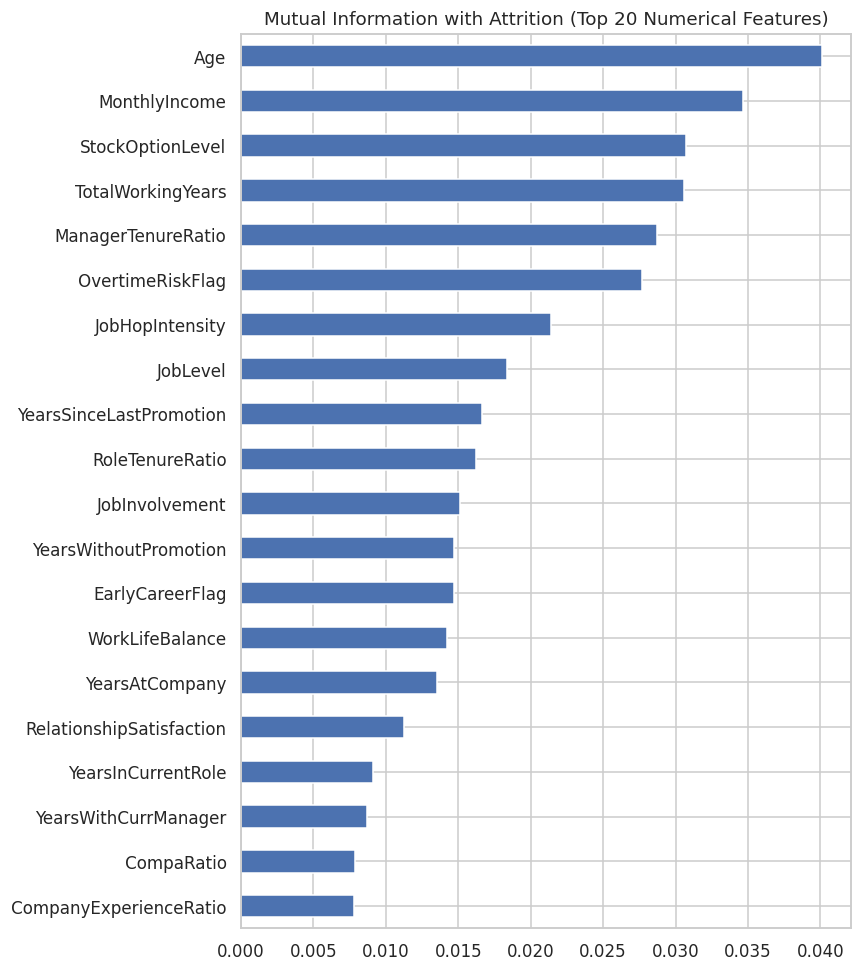

,Mutual Information
Age,0.040
MonthlyIncome,0.035
StockOptionLevel,0.031
TotalWorkingYears,0.031
ManagerTenureRatio,0.029
OvertimeRiskFlag,0.028
JobHopIntensity,0.021
JobLevel,0.018
YearsSinceLastPromotion,0.017
RoleTenureRatio,0.016


In [27]:
mi_scores = mutual_info_classif(
    df[numeric_eval_cols].fillna(0), df["AttritionFlag"], random_state=RANDOM_STATE
)
mi_table = (
    pd.Series(mi_scores, index=numeric_eval_cols)
    .sort_values(ascending=False)
    .rename("Mutual Information")
    .to_frame()
)

fig, ax = plt.subplots(figsize=(8, 9))
mi_table.head(20)["Mutual Information"].plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_title("Mutual Information with Attrition (Top 20 Numerical Features)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mi_table.head(10)


### Feature-by-feature evaluation decisions

| Feature evaluated | Method | Evidence | Decision | Justification |
|---|---|---|---|---|
| `JobLevel` vs `MonthlyIncome` | Correlation | r ≈ 0.95 | **Retain both** | Both individually meaningful for business reporting; `CompaRatio` was engineered specifically to give a decorrelated pay-competitiveness view, so the redundancy is already mitigated downstream. |
| `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager` | Correlation + Spearman test (Part 3, Test 5) | r/ρ in the 0.71–0.84 range | **Retain, flag for Week 4** | Meaningful multicollinearity for linear/logistic models. Recorded here as a modelling note rather than removed now, since tree-based models (a likely Week 4 candidate) are largely insensitive to it. |
| `DistanceFromHome` vs `LongCommuteFlag` | Correlation | r ≈ 0.88 (by construction — the flag is a threshold on the same column) | **Remove `LongCommuteFlag`** | It is a deterministic re-encoding of `DistanceFromHome` (a ≥15-mile cutoff) and adds no information beyond the continuous column; its mutual information (0.0038) is also lower than `DistanceFromHome`'s (0.0077). |
| `PercentSalaryHike` vs `PerformanceRating` | Correlation + variance check | r ≈ 0.77; `PerformanceRating` has only 2 distinct values (3 or 4) in the entire dataset | **Retain, note limited value** | Both show ~0 mutual information with the target. Kept for completeness/business interpretability, but flagged as low analytical value — the near-constant `PerformanceRating` scale is a genuine dataset limitation, not a coding error. |
| `StagnationRiskFlag` | Mutual information | MI ≈ 0.000 despite a real gap in group attrition rates (29.6% vs 15.9%, Part 4.4) | **Retain** | Mutual information estimated on a rare binary flag (≈1.8% of employees) is unstable with this sample size; the raw group-rate evidence is more trustworthy here and the feature is domain-justified as an interaction signal. Documented as a limitation, not discarded. |
| `SatisfactionIndex`, `CompaRatio`, `JobHopIntensity` | Mutual information | `JobHopIntensity` ranks in the top 10 of all numerical features; `SatisfactionIndex` and `CompaRatio` rank lower but non-zero | **Retain all** | Each is directly motivated by a Part 2/3 finding; low individual mutual information does not rule out value in combination with other features during Week 4 modelling. |


In [28]:
columns_to_drop = ["LongCommuteFlag"]
print("Columns removed in Week 3 based on the evaluation above:", columns_to_drop)


Columns removed in Week 3 based on the evaluation above: ['LongCommuteFlag']


## Part 6: Dataset Refinement — Final Modelling Dataset

The Week 2 cleaning and preprocessing process is **not** repeated. The only changes applied here are: adding the four Week 3 engineered features, and removing the one redundant feature identified in Part 5.


In [29]:
final_df = df.drop(columns=columns_to_drop, errors="ignore").copy()

print("Shape before refinement (Week 2 cleaned dataset):", df.shape)
print("Columns added in Week 3:", week3_engineered_features)
print("Columns removed in Week 3:", columns_to_drop)
print("Shape after refinement (final modelling dataset):", final_df.shape)

refinement_summary = pd.DataFrame({
    "Item": [
        "Week 2 cleaned dataset — rows", "Week 2 cleaned dataset — columns",
        "New features added in Week 3", "Features removed in Week 3",
        "Final modelling dataset — rows", "Final modelling dataset — columns",
        "Statistical tests performed", "Visualisations produced"
    ],
    "Value": [
        df.shape[0], df.shape[1],
        len(week3_engineered_features), len(columns_to_drop),
        final_df.shape[0], final_df.shape[1],
        5, 14
    ]
})
refinement_summary


Shape before refinement (Week 2 cleaned dataset): (1470, 46)
Columns added in Week 3: ['SatisfactionIndex', 'CompaRatio', 'JobHopIntensity', 'StagnationRiskFlag']
Columns removed in Week 3: ['LongCommuteFlag']
Shape after refinement (final modelling dataset): (1470, 45)


,Item,Value
0,Week 2 cleaned dataset — rows,1470
1,Week 2 cleaned dataset — columns,46
2,New features added in Week 3,4
3,Features removed in Week 3,1
4,Final modelling dataset — rows,1470
5,Final modelling dataset — columns,45
6,Statistical tests performed,5
7,Visualisations produced,14


In [30]:
final_df.to_csv("employee_attrition_final_modelling_dataset.csv", index=False)
print("Saved: employee_attrition_final_modelling_dataset.csv")
print(f"Shape: {final_df.shape}")

output_files = ["employee_attrition_final_modelling_dataset.csv"]

try:
    from google.colab import files

    for file in output_files:
        files.download(file)

except ImportError:
    print("Automatic download is available when running in Google Colab.")


Saved: employee_attrition_final_modelling_dataset.csv
Shape: (1470, 45)
Automatic download is available when running in Google Colab.


## Summary and Next Steps

This notebook extended the Week 2 cleaned dataset with 14 advanced visualisations, 5 statistical hypothesis tests, and 4 newly engineered features, then produced a refined **final modelling dataset** (`employee_attrition_final_modelling_dataset.csv`).

**Headline findings:**
- Overtime, marital status, and monthly income are all statistically significantly associated with attrition (Tests 1–3).
- Job satisfaction does **not** differ significantly by job role (Test 4) — role-level attrition differences are better explained by workload/overtime/pay than by reported satisfaction.
- `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` are strongly intercorrelated — a multicollinearity note carried forward to Week 4.
- `CompaRatio` and `JobHopIntensity` add de-confounded, non-redundant signal beyond the Week 2 feature set.

**Next steps (Week 4):** the final modelling dataset produced here is ready for the scaling/encoding/train-test-split pipeline from Week 2, followed by classification model development (e.g. logistic regression as an interpretable baseline, plus a tree-based model), evaluation with attrition-appropriate metrics (recall/precision/ROC-AUC given class imbalance), and translation of feature importances into business recommendations.

See the accompanying **Business Insights and Recommendations Report** for the client-facing narrative version of these findings.
